In [ ]:
#| hide

import os
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import igl

In [ ]:
#| hide

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
from jaxtyping import Float

In [ ]:
#| hide

from triangulax.mesh import HeMesh
from triangulax import geometry as geom, adjacency as adj, linops, elastic, algorithms as alg
from triangulax.triangular import read_obj, write_obj

# Convergence of the discrete differential-geometry operators

This notebook studies how the discretised operators in `triangulax` behave as a mesh is refined,
by comparing them against exact values on surfaces defined by an implicit equation $F(x,y,z)=0$. As usual in the finite-element method, it is important to be precise about what convergence means:

1. **Differential operators** — the finite-element **gradient** (`linops.compute_gradient_3d`) and
   the cotangent **Laplace–Beltrami** operator (`linops.compute_cotan_laplace`) — converge
   *pointwise*: $O(h)$ on curved surfaces, exact on flat meshes.
2. **Pointwise curvatures** — Gaussian (`geom.get_gaussian_curvature`) and mean
   (`geom.get_mean_curvature_laplace`) — do not converge pointwise on general meshes, but they
   are stable: the error stays bounded and does not blow up.
3. **Region-integrated curvatures** — the same estimators averaged over a **fixed** region — do
   converge. This means the operators converge weakly, as measures. We verify it, including for the
   metric and the second fundamental form.

We test five surfaces at five resolutions each. The convergence we check is guaranteed also theoretically:
- [Wardetzky: Discrete Differential Operators on Polyhedral Surfaces - Convergence and Approximation](https://refubium.fu-berlin.de/handle/fub188/3519)
- [Cohen-Steiner and Morvan: Restricted delaunay triangulations and normal cycle](https://dl.acm.org/doi/10.1145/777792.777839)

Importantly, convergence under refinement is only guaranteed if the mesh quality (e.g. triangle deformation) is preserved. If triangles become degenerate, even the area of a surface may not converge to its continuum counterpart (https://www.mathcounterexamples.net/the-schwarz-lantern/).

## 1. Test meshes

Each mesh is built from an isotropic remesh (`plane_*`, `sphere_*`, `torus_*` in
`refinement_tests/`, at resolutions = edge length as % of the bounding-box diagonal, so `4` is
coarsest and `0.25` finest) by:

1. Moving its vertices exactly onto the target surface (project to the sphere / torus apply a
   height deformation for the saddle and an anisotropic scaling for the ellipsoid), then
2. Flipping non-Delaunay edges with `alg.fix_delaunay`. This ensures mesh quality.

The five surfaces are the **plane** ($K=H=0$), a **saddle** $z=\tfrac12(x^2-y^2)$ (a hyperbolic
paraboloid, open), the unit **sphere**, an **ellipsoid** (sphere scaled by $(1,0.8,0.6)$), and a
**torus** (radii $1,\,0.25$). Delaunay-fixing is slow on the finest meshes, so the meshes are
generated once and saved to `refinement_tests/delaunay/`; re-running skips meshes
that already exist.

In [ ]:
#| hide

RESOLUTIONS = [4, 2, 1, 0.5, 0.25]                 # 4 = coarsest, 0.25 = finest
SURFACES = ["plane", "saddle", "sphere", "ellipsoid", "torus"]
CLOSED = {"sphere", "ellipsoid", "torus"}          # closed = no boundary
ELLIPSOID_AXES = (1.0, 0.8, 0.6); SADDLE_AMPLITUDE = 0.5; TORUS_A, TORUS_C = 1.0, 0.25
RAW_DIR = "tutorial_meshes/refinement_tests"; FIXED_DIR = "tutorial_meshes/refinement_tests/delaunay"
COLORS = {"sphere": "tab:blue", "ellipsoid": "tab:orange", "torus": "tab:green",
          "saddle": "tab:red", "plane": "tab:gray"}

def _project_sphere(v, radius=1.0):
    v = v - v.mean(0)
    return radius * jnp.asarray((v.T / np.linalg.norm(v, axis=1)).T)

def _project_torus(v, a=TORUS_A, c=TORUS_C):
    v = jnp.roll(v, 1, axis=1)
    theta = jnp.arctan2(v[:, 1], v[:, 0])
    center = a * jnp.stack([jnp.cos(theta), jnp.sin(theta), jnp.zeros_like(theta)], 1)
    d = v - center; d = d / jnp.linalg.norm(d, axis=1, keepdims=True)
    v = center + c * d
    return v - v.mean(0)

def make_surface_vertices(surface, res):
    """Load the raw remesh and move its vertices exactly onto the target surface."""
    base = {"plane": "plane", "saddle": "plane", "sphere": "sphere",
            "ellipsoid": "sphere", "torus": "torus"}[surface]
    v, f = read_obj(f"{RAW_DIR}/{base}_{res}.obj", dim=3)
    if surface == "sphere":      v = _project_sphere(v)
    elif surface == "ellipsoid": v = _project_sphere(v) * jnp.array(ELLIPSOID_AXES)
    elif surface == "torus":     v = _project_torus(v)
    elif surface == "plane":     v = jnp.roll(v, 1, axis=1); v = v - v.mean(0)
    elif surface == "saddle":
        v = jnp.roll(v, 1, axis=1); v = v - v.mean(0)
        v = v.at[:, 2].set(SADDLE_AMPLITUDE * (v[:, 0]**2 - v[:, 1]**2))
    return v, f

def resfmt(r): return str(int(r)) if float(r) == int(r) else str(r)

def generate_one(job):
    """Worker: build one surface mesh, flip to Delaunay, and save it. Runs in a separate process."""
    surface, res = job
    v, f = make_surface_vertices(surface, res)
    hemesh_fixed, n_flips = alg.fix_delaunay(v, HeMesh.from_triangles(v.shape[0], f), max_iters=30)
    write_obj(v, np.asarray(hemesh_fixed.faces), f"{FIXED_DIR}/{surface}_{resfmt(res)}.obj")
    return surface, res, int(n_flips)

In [ ]:
#| hide

# Generate the Delaunay-fixed meshes once, in parallel across surfaces/resolutions (skips existing).
os.makedirs(FIXED_DIR, exist_ok=True)
jobs = [(s, r) for s in SURFACES for r in RESOLUTIONS
        if not os.path.exists(f"{FIXED_DIR}/{s}_{resfmt(r)}.obj")]
if jobs:
    print(f"generating {len(jobs)} meshes (Delaunay flips can take minutes on the finest meshes)...")
    with ProcessPoolExecutor(max_workers=min(5, os.cpu_count()), mp_context=mp.get_context("fork")) as ex:
        for surface, res, n_flips in ex.map(generate_one, jobs):
            print(f"  {surface:10s} res={resfmt(res):>4}: {n_flips} edges flipped")
else:
    print("all Delaunay-fixed meshes already present")

all Delaunay-fixed meshes already present


In [ ]:
#| hide

def load_mesh(surface, res):
    v, f = read_obj(f"{FIXED_DIR}/{surface}_{resfmt(res)}.obj", dim=3)
    return v, HeMesh.from_triangles(v.shape[0], f)

# Load every (surface, resolution) mesh once into a single dictionary.
MESHES = {(s, r): load_mesh(s, r) for s in SURFACES for r in RESOLUTIONS}
print("loaded", len(MESHES), "meshes; vertex counts (finest):",
      {s: int(MESHES[(s, min(RESOLUTIONS))][0].shape[0]) for s in SURFACES})

loaded 25 meshes; vertex counts (finest): {'plane': 87917, 'saddle': 87917, 'sphere': 187068, 'ellipsoid': 187068, 'torus': 152088}


## 2. Analytical reference values

For a surface defined implicitly by as a level set $F(x,y,z)=0$, the Gaussian and mean curvatures admit simple formulas [Goldman 2005](https://doi.org/10.1016/j.cagd.2005.06.005), which we evaluate by automatic differentiation 

$$K=\frac{\nabla F^{\top}\operatorname{adj}(\mathbf H_F)\nabla F}{|\nabla F|^4},\qquad
H=\frac{|\nabla F|^2\operatorname{tr}(\mathbf H_F)-\nabla F^{\top}\mathbf H_F\nabla F}{2|\nabla F|^3},$$

The sign is fixed so an outward-oriented sphere has $H=+1/R$. The next cell checks this against the closed forms for the sphere ($K=1/R^2$, $H=1/R$) and the ellipsoid.

In [13]:
def implicit_curvatures(F, x: Float[jax.Array, "3"]):
    """Gaussian K, mean H, and unit normal at a point x on the implicit surface F(x) = 0 (Goldman 2005)."""
    g = jax.grad(F)(x); Hess = jax.hessian(F)(x); gn2 = g @ g
    adj_H = jnp.array([
        [Hess[1,1]*Hess[2,2]-Hess[1,2]*Hess[2,1], Hess[0,2]*Hess[2,1]-Hess[0,1]*Hess[2,2], Hess[0,1]*Hess[1,2]-Hess[0,2]*Hess[1,1]],
        [Hess[1,2]*Hess[2,0]-Hess[1,0]*Hess[2,2], Hess[0,0]*Hess[2,2]-Hess[0,2]*Hess[2,0], Hess[0,2]*Hess[1,0]-Hess[0,0]*Hess[1,2]],
        [Hess[1,0]*Hess[2,1]-Hess[1,1]*Hess[2,0], Hess[0,1]*Hess[2,0]-Hess[0,0]*Hess[2,1], Hess[0,0]*Hess[1,1]-Hess[0,1]*Hess[1,0]]])
    K = (g @ adj_H @ g) / gn2**2
    H = (gn2*jnp.trace(Hess) - g @ Hess @ g) / (2 * gn2**1.5)
    return K, H, g / jnp.sqrt(gn2)

A_ELL, B_ELL, C_ELL = ELLIPSOID_AXES
IMPLICIT = {
    "sphere":    lambda x: x @ x - 1.0,
    "ellipsoid": lambda x: (x[0]/A_ELL)**2 + (x[1]/B_ELL)**2 + (x[2]/C_ELL)**2 - 1.0,
    "torus":     lambda x: (jnp.sqrt(x[0]**2 + x[1]**2) - TORUS_A)**2 + x[2]**2 - TORUS_C**2,
    "saddle":    lambda x: x[2] - SADDLE_AMPLITUDE * (x[0]**2 - x[1]**2),
    "plane":     lambda x: x[2],
}
def analytic_curvature(name, points):
    """Exact (K, H, unit normal) at each point, from the implicit representation."""
    return jax.vmap(lambda x: implicit_curvatures(IMPLICIT[name], x))(points)

In [14]:
# closed forms (Wikipedia) used only to validate the autodiff implementation
def sphere_KH(R=1.0): return 1/R**2, 1/R
def ellipsoid_KH(x, a=A_ELL, b=B_ELL, c=C_ELL):
    q = (x[...,0]/a**2)**2 + (x[...,1]/b**2)**2 + (x[...,2]/c**2)**2
    return 1/((a*b*c)**2*q**2), jnp.abs(x[...,0]**2+x[...,1]**2+x[...,2]**2-a**2-b**2-c**2)/(2*(a*b*c)**2*q**1.5)

key = jax.random.PRNGKey(0); p = jax.random.normal(key, (500, 3))
p_sphere = p/jnp.linalg.norm(p, axis=1, keepdims=True); p_ellip = p_sphere*jnp.array(ELLIPSOID_AXES)
for name, pts, (Kc, Hc) in [("sphere", p_sphere, sphere_KH()), ("ellipsoid", p_ellip, ellipsoid_KH(p_ellip))]:
    K, H, _ = analytic_curvature(name, pts)
    print(f"{name:10s} max|K-K_closed|={float(jnp.max(jnp.abs(K-Kc))):.1e}  max|H-H_closed|={float(jnp.max(jnp.abs(H-Hc))):.1e}")

sphere     max|K-K_closed|=4.4e-16  max|H-H_closed|=4.4e-16
ellipsoid  max|K-K_closed|=2.7e-15  max|H-H_closed|=1.8e-15


### Error metric and reference integrals

For a quantity $A$ we report the **relative error, normalized by the surface-average magnitude**,
$|A_{\rm exact}-A_{\rm disc}|/\overline{|A|}$ with $\overline{|A|}=\int_S|A|\,dA/\int_S dA$.
Both $\overline{|A|}$ and the exact region integrals come from a fine parametric quadrature of each surface, which also fixes the
**sectors** used later: 8 octants (ellipsoid, by coordinate sign), 8 poloidal bands (torus), and 8 angular sectors inside a disk of radius $0.8$ (saddle).

In [ ]:
#| hide

def mean_edge_length(v, h): return float(geom.get_he_length(v, h).mean())
def align_sign(H, n, v, h): return H * jnp.sign(jnp.sum(geom.get_vertex_normals(v, h) * n))

def surface_quadrature(name):
    """Fine parametric quadrature: returns points, exact K/H, area element dA, and a 0..7 sector id."""
    if name == "sphere":
        nt, npp = 1000, 1400; TH, PH = np.meshgrid((np.arange(nt)+.5)*np.pi/nt, (np.arange(npp)+.5)*2*np.pi/npp, indexing="ij")
        X, Y, Z = np.sin(TH)*np.cos(PH), np.sin(TH)*np.sin(PH), np.cos(TH); dA = np.sin(TH)*(np.pi/nt)*(2*np.pi/npp)
        sec = ((X>0)+2*(Y>0)+4*(Z>0)).astype(int)
    elif name == "ellipsoid":
        nt, npp = 1200, 1600; TH, PH = np.meshgrid((np.arange(nt)+.5)*np.pi/nt, (np.arange(npp)+.5)*2*np.pi/npp, indexing="ij")
        X, Y, Z = A_ELL*np.sin(TH)*np.cos(PH), B_ELL*np.sin(TH)*np.sin(PH), C_ELL*np.cos(TH)
        rth = np.stack([A_ELL*np.cos(TH)*np.cos(PH), B_ELL*np.cos(TH)*np.sin(PH), -C_ELL*np.sin(TH)], -1)
        rph = np.stack([-A_ELL*np.sin(TH)*np.sin(PH), B_ELL*np.sin(TH)*np.cos(PH), 0*TH], -1)
        dA = np.linalg.norm(np.cross(rth, rph), axis=-1)*(np.pi/nt)*(2*np.pi/npp); sec = ((X>0)+2*(Y>0)+4*(Z>0)).astype(int)
    elif name == "torus":
        nt, npp = 1200, 1600; TH, PH = np.meshgrid((np.arange(nt)+.5)*2*np.pi/nt-np.pi, (np.arange(npp)+.5)*2*np.pi/npp, indexing="ij")
        rr = TORUS_A+TORUS_C*np.cos(TH); X, Y, Z = rr*np.cos(PH), rr*np.sin(PH), TORUS_C*np.sin(TH)
        dA = (TORUS_C*rr)*(2*np.pi/nt)*(2*np.pi/npp); sec = np.clip(np.floor(8*(TH+np.pi)/(2*np.pi)).astype(int), 0, 7)  # poloidal bands
    elif name == "saddle":
        r0, nr, na = 0.8, 900, 1600; RHO, AL = np.meshgrid((np.arange(nr)+.5)*r0/nr, (np.arange(na)+.5)*2*np.pi/na, indexing="ij")
        X, Y, Z = RHO*np.cos(AL), RHO*np.sin(AL), SADDLE_AMPLITUDE*((RHO*np.cos(AL))**2-(RHO*np.sin(AL))**2)
        dA = np.sqrt(1+4*SADDLE_AMPLITUDE**2*(X**2+Y**2))*RHO*(r0/nr)*(2*np.pi/na); sec = np.clip(np.floor(8*AL/(2*np.pi)).astype(int), 0, 7)
    P = np.stack([X, Y, Z], -1).reshape(-1, 3)
    K, H, _ = analytic_curvature(name, jnp.asarray(P))
    return dict(P=P, K=np.asarray(K), H=np.asarray(H), dA=dA.reshape(-1), sec=sec.reshape(-1))

QUAD = {n: surface_quadrature(n) for n in ["sphere", "ellipsoid", "torus", "saddle"]}
def mean_abs(name, field):  # area-weighted surface mean of |K| or |H|
    q = QUAD[name]; return float((np.abs(q[field])*q["dA"]).sum()/q["dA"].sum())
def smooth_sector(name, field):  # per-sector exact average <field>_P and area
    q = QUAD[name]; return {o: ((q[field][q["sec"]==o]*q["dA"][q["sec"]==o]).sum()/q["dA"][q["sec"]==o].sum(),
                                q["dA"][q["sec"]==o].sum()) for o in range(8)}
def sector_id(name, pts):
    p = np.asarray(pts)
    if name in ("sphere", "ellipsoid"): return ((p[:,0]>0)+2*(p[:,1]>0)+4*(p[:,2]>0)).astype(int)
    if name == "torus":
        th = np.arctan2(p[:,2], np.sqrt(p[:,0]**2+p[:,1]**2)-TORUS_A); return np.clip(np.floor(8*(th+np.pi)/(2*np.pi)).astype(int), 0, 7)
    if name == "saddle":
        sid = np.clip(np.floor(8*(np.arctan2(p[:,1], p[:,0])%(2*np.pi))/(2*np.pi)).astype(int), 0, 7)
        return np.where(p[:,0]**2+p[:,1]**2 < 0.8**2, sid, -1)     # -1 excludes the boundary rim

## 3. Differential operators converge pointwise

We first check the two operators that *do* converge pointwise. The finite-element **gradient** is
tested on the ambient-linear field $u=a\cdot x$, whose exact surface gradient is the tangential
projection $a-(a\cdot n)\,n$ (with the smooth normal $n$). The area-normalised cotangent
**Laplace–Beltrami** operator is tested on eigen/harmonic fields: on the sphere $\Delta_S z=-2z$, on
the plane $\Delta(x^2+y^2)=4$. Errors are RMS over faces/vertices, normalised as above. Because the
flat-mesh error is at machine precision while the curved-surface error is $O(h)$, the $y$-axis is
**broken** into two ranges.

/var/folders/vm/1jl6rjln6n9cjt54vsr9n4800000gr/T/ipykernel_76998/2921015705.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, w_pad=0.4, h_pad=0.1)
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found

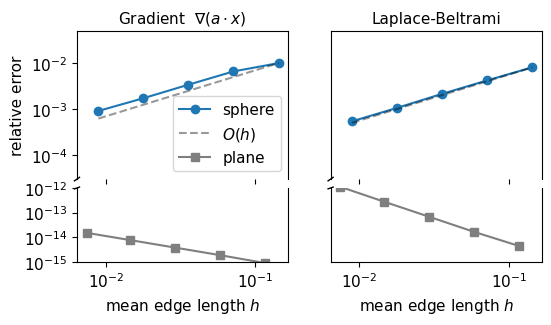

In [ ]:
#| echo: false

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 11}

mpl.rc('font', **font)

a_vec = jnp.array([1.0, 2.0, -1.0])
def gradient_error(name):
    hs, err = [], []
    for r in RESOLUTIONS:
        v, h = MESHES[(name, r)]; g = np.asarray(linops.compute_gradient_3d(v, h, v @ a_vec))
        cen = np.asarray(v[h.faces].mean(1)); _, _, n = analytic_curvature(name, jnp.asarray(cen)); n = np.asarray(n)
        ge = np.asarray(a_vec) - np.sum(np.asarray(a_vec)*n, 1, keepdims=True)*n
        fa = np.asarray(elastic.get_area_from_metric(elastic.get_metric(v, h)))
        nz = (np.linalg.norm(ge, axis=1)*fa).sum()/fa.sum()
        hs.append(mean_edge_length(v, h)); err.append(np.sqrt((np.sum((g-ge)**2, 1)*fa).sum()/fa.sum())/nz)
    return hs, err
def laplace_error(name, field, exact, interior):
    hs, err = [], []
    for r in RESOLUTIONS:
        v, h = MESHES[(name, r)];
        lap = np.asarray(linops.compute_cotan_laplace(v, h, field(v), normalize=True));
        ex = np.asarray(exact(v))
        A = np.asarray(geom.get_voronoi_areas_robust(v, h)); m = ~np.asarray(h.is_bdry) if interior else np.ones(len(ex), bool)
        nz = (np.abs(ex[m])*A[m]).sum()/A[m].sum()
        hs.append(mean_edge_length(v, h)); err.append(np.sqrt((((lap-ex)[m])**2*A[m]).sum()/A[m].sum())/nz)
    return hs, err

data = {"grad_sphere": gradient_error("sphere"), "grad_plane": gradient_error("plane"),
        "lap_sphere": laplace_error("sphere", lambda v: v[:,2], lambda v: -2*v[:,2], False),
        "lap_plane": laplace_error("plane", lambda v: v[:,0]**2+v[:,1]**2, lambda v: jnp.full(len(v), 4.0), True)}

fig, ax = plt.subplots(2, 2, figsize=(6, 3), sharex="col", gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))
for col, (S, P, title) in enumerate([(data["grad_sphere"], data["grad_plane"], r"Gradient  $\nabla(a\cdot x)$"),
                                      (data["lap_sphere"], data["lap_plane"], "Laplace-Beltrami")]):
    top, bot = ax[0, col], ax[1, col]
    top.loglog(S[0], S[1], 'o-', color="tab:blue", label="sphere")
    bot.loglog(P[0], P[1], 's-', color="tab:gray", label="plane (flat)")
    hr = np.array([min(S[0]), max(S[0])]); top.loglog(hr, S[1][0]/S[0][0]*hr, 'k--', alpha=.4, label="$O(h)$")
    top.set_ylim(3e-5, 5e-2);
    bot.set_ylim(1e-15, 1e-12); 
    top.set_title(title, fontsize=11)
    top.spines['bottom'].set_visible(False);
    bot.spines['top'].set_visible(False);
    top.tick_params(labelbottom=False)
    dd = .012
    top.plot([-dd, dd], [-dd, dd], transform=top.transAxes, color='k', clip_on=False, lw=1)
    bot.plot([-dd, dd], [1-dd, 1+dd], transform=bot.transAxes, color='k', clip_on=False, lw=1)
    bot.set_xlabel("mean edge length $h$");
    top.loglog([], [], 's-', color="tab:gray", label="plane")
    top.minorticks_off()
    bot.minorticks_off()


ax[0, 0].set_ylabel("relative error")

ax[0,0].legend(fontsize=11, loc="lower right");
ax[0,1].set_yticks([],[])
ax[1,1].set_yticks([],[])



plt.tight_layout(pad=0.1, w_pad=0.4, h_pad=0.1)
plt.savefig("tutorials/tutorial_plots/convergence_test_Laplace_gradient.pdf")

plt.show()



Both operators converge pointwise $O(h)$ on the sphere and machine-exact on the plane (the P1 gradient of a linear field is exact on each triangle, and the cotan Laplacian is exact for the quadratic on a flat mesh).

## 4. Pointwise curvature: stable, but not convergent

The curvature estimators only converge in the weak sense. Below, the **median** pointwise error (bulk behavior) and
the **maximum** pointwise error (worst vertex) are shown for $K$ and $H$ on the sphere and the ellipsoid. On the near-regular sphere the median converges like $O(h^2)$, but on the ellipsoid, where the mesh is less regular, the median does not decrease. The maximum error stays bounded under refinement on both surfaces: the estimators are pointwise **stable**.

We also compare two discretizations of the mean curvature, using Laplace operator + Voronoi areas (`get_mean_curvature_laplace`, recommended), and dihedral angles + barycentric area.

Note that our implementation matches the `libigl` to machine precision -- lack of pointwise convergence is a property of the discretisation, not a bug.

In [98]:
def get_mean_curvature_dihedral_barycentric(vertices, hemesh):
    H_dihedral = geom.get_mean_curvature_dihedral(vertices, hemesh, normalize=False)
    return H_dihedral / geom.get_barycentric_cell_areas(vertices, hemesh)

findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not

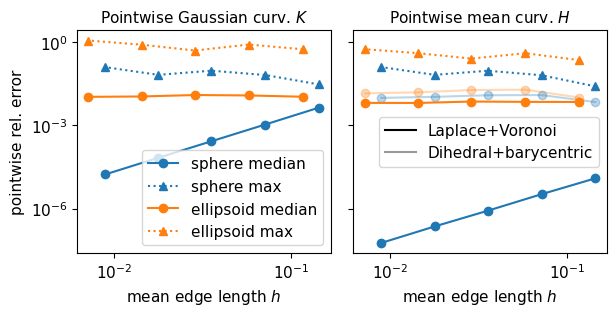

In [ ]:
#| echo: false

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 11}

mpl.rc('font', **font)

fig, ax = plt.subplots(1, 2, figsize=(6, 3),sharey=True)
for name in ["sphere", "ellipsoid"]:
    hs, Km, KM, Hm, HM, Hdm, HdM = [], [], [], [], [], [], [] 
    for r in RESOLUTIONS:
        v, h = MESHES[(name, r)]; Kx, Hx, nx = analytic_curvature(name, v); Hx = align_sign(Hx, nx, v, h)
        eK = np.abs(np.asarray(geom.get_gaussian_curvature(v, h) - Kx)) / mean_abs(name, "K")
        eH = np.abs(np.asarray(geom.get_mean_curvature_laplace(v, h) - Hx)) / mean_abs(name, "H")
        eHd = np.abs(np.asarray(get_mean_curvature_dihedral_barycentric(v, h) - Hx)) / mean_abs(name, "H")

        hs.append(mean_edge_length(v, h));
        Km.append(np.median(eK)); KM.append(eK.max());
        Hm.append(np.median(eH)); HM.append(eH.max())
        Hdm.append(np.median(eHd)); HdM.append(eHd.max())
    ax[0].loglog(hs, Km, 'o-', color=COLORS[name], label=f"{name} median");
    ax[0].loglog(hs, KM, '^:', color=COLORS[name], alpha=1, label=f"{name} max")
    ax[1].loglog(hs, Hm, 'o-', color=COLORS[name]);
    ax[1].loglog(hs, HM, '^:', color=COLORS[name], alpha=1)
    ax[1].loglog(hs, Hdm, 'o', ls="-", color=COLORS[name], alpha=0.3);


ax[0].set_title("Pointwise Gaussian curv. $K$", fontsize=11);
ax[1].set_title("Pointwise mean curv. $H$", fontsize=11)
for a in ax:
    a.set_xlabel("mean edge length $h$");


ax[0].set_ylabel("pointwise rel. error");

ax[0].legend();
ax[0].set_yticks([1e-0, 1e-2, 1e-4])
ax[1].set_yticks([1e-0, 1e-3, 1e-6])

ax[1].plot([],[], ls="-", color="k", alpha=1, label="Laplace+Voronoi")
ax[1].plot([],[], ls="-", color="k", alpha=0.4, label="Dihedral+barycentric")
ax[1].legend();

ax[0].minorticks_off()
ax[1].minorticks_off()

plt.tight_layout(pad=0.1, w_pad=0.4, h_pad=0.1)
plt.savefig("tutorials/tutorial_plots/convergence_test_pointwise.pdf")
plt.show()



## 5. What convergence to expect

The behaviour above is exactly what the literature predicts. The angle-defect and cotangent curvature estimators are **not** guaranteed to converge pointwise on general meshes; they converge in an **integrated / weak ("measure")** sense.

- **Gaussian curvature (angle defect).** The defect $2\pi-\sum_i\theta_i$ is the *integral* of $K$ over the cell around a vertex (up to higher order); over a closed surface it is exactly $2\pi\chi$ (Gauss–Bonnet). Divided by the cell area it converges pointwise only for meshes with special regularity properties. However, Cohen-Steiner & Morvan prove that discrete curvature **measures** converge over any fixed region, linearly $O(h)$ in the sampling density.
- **Mean curvature (cotangent).** The cotan Laplacian converges to its smooth counterpart, but the mean curvature vector $\tfrac12 M^{-1}Lx=Hn$ converges only in the sense of **distributions** (Wardetzky 2008).

The remedy is to integrate the estimators over regions of **fixed** size (that do not shrink as $h\to0$), instead of looking per-vertex values (integrated over cells whose area goes to 0).

## 6. Region-averaged curvature converges

We split each surface into 8 fixed sectors and test $\int_P A\,dA=\int_P A\,dA/\int_P dA$ using the **un-normalised** (integrated) estimators — $\int_P H\,dA\approx\sum_{i\in P}$ `get_mean_curvature_*(..., normalize=False)`, $\int_P K\,dA\approx\sum_{i\in P}(2\pi-\sum\theta)_i$, patch area $\sum_{i\in P}A_i$ — for the torus, ellipsoid, and saddle. We plot the median error over the 8 sectors of the mean and Gaussian curvatures. 

findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not

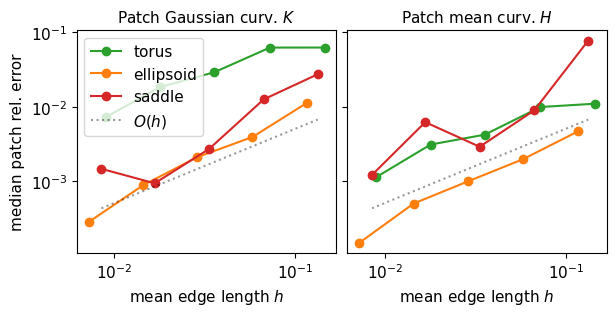

In [ ]:
#| echo: false

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 11}

mpl.rc('font', **font)

def patch_curvature_errors(name):
    sH, sK = smooth_sector(name, "H"), smooth_sector(name, "K"); nH, nK = mean_abs(name, "H"), mean_abs(name, "K")
    hs, eHl, eK = [], [], []
    for r in RESOLUTIONS:
        v, h = MESHES[(name, r)]; _, _, nx = analytic_curvature(name, v);
        s = float(jnp.sign(jnp.sum(geom.get_vertex_normals(v, h)*nx)))
        H_lap = s*np.asarray(geom.get_mean_curvature_laplace(v, h, normalize=False))
        K_int = 2*np.pi - np.asarray(geom.get_angle_sum(v, h))
        A = np.asarray(geom.get_voronoi_areas_robust(v, h)); A_bary = np.asarray(geom.get_barycentric_cell_areas(v, h))
        sid = sector_id(name, v); vHl, vK, vHb = [], [], []
        for o in range(8):
            m = sid == o
            if m.sum() == 0: continue
            vHl.append(abs(H_lap[m].sum()/A[m].sum() - sH[o][0])/nH)
            vK.append(abs(K_int[m].sum()/A[m].sum() - sK[o][0])/nK)
        hs.append(mean_edge_length(v, h)); eHl.append(np.median(vHl)); eK.append(np.median(vK))
    return hs, eHl, eK

fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
for name in ["torus", "ellipsoid", "saddle"]:
    hs, eHl, eK = patch_curvature_errors(name)
    ax[0].loglog(hs, eK, 'o-', color=COLORS[name], label=name);
    ax[1].loglog(hs, eHl, 'o-', color=COLORS[name]);

hr = np.array([min(hs), max(hs)])
for a, t in zip(ax, ["Patch Gaussian curv. $K$", "Patch mean curv. $H$",]):
    a.loglog(hr, a.get_ylim()[0]*4*(hr/hr[0]), 'k:', alpha=.4, label="$O(h)$");
    a.set_title(t, fontsize=11);
    a.set_xlabel("mean edge length $h$");

ax[0].set_ylabel("median patch rel. error");
ax[0].legend();
ax[0].set_yticks([1e-1, 1e-2, 1e-3])
ax[1].set_yticks([1e-1, 1e-2, 1e-3])
ax[0].minorticks_off()
ax[1].minorticks_off()


plt.tight_layout(pad=0.1, w_pad=0.4, h_pad=0.1)
plt.savefig("tutorials/tutorial_plots/convergence_test_integrated.pdf")
plt.show()


**Region averages converge**, at roughly the $O(h)$ rate the measure theory predicts, for all three surfaces — in contrast to the flat pointwise estimates. Two torus converges more slowly than the others — its mesh is the least regular.

## 7. Region-averaged metric and second fundamental form

The same holds for the first and second fundamental forms. We test the **patch area** from the
metric ($\sum_{f\in P}\tfrac12\sqrt{\det g}$ vs $\int_P dA$) and the **patch mean curvature** from
the shape operator $S=g^{-1}b$ built with `elastic.get_second_fundamental_form` (an area-weighted
per-face average $\sum_f H_f\,A_f/\sum_f A_f$ vs $\int_P H\,dA$). Faces are assigned to sectors by
their centroid.

findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not

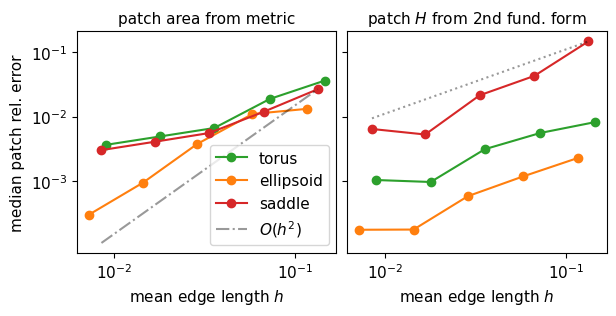

In [ ]:
#| echo: false

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 11}

mpl.rc('font', **font)

def patch_metric_errors(name):
    sH, nH = smooth_sector(name, "H"), mean_abs(name, "H"); q = QUAD[name]
    area_o = {o: q["dA"][q["sec"] == o].sum() for o in range(8)}
    hs, eA, eH = [], [], []
    for r in RESOLUTIONS:
        v, h = MESHES[(name, r)]; cen = np.asarray(v[h.faces].mean(1)); sid = sector_id(name, cen)
        fa = np.asarray(elastic.get_area_from_metric(elastic.get_metric(v, h)))
        S = elastic.get_two_x_two_inverse(elastic.get_metric(v, h)) @ elastic.get_second_fundamental_form(v, h)
        Hf = 0.5*np.asarray(jnp.trace(S, axis1=1, axis2=2))
        _, _, nx = analytic_curvature(name, jnp.asarray(cen));
        Hf *= float(np.sign((np.asarray(geom.get_triangle_normals(v, h))*np.asarray(nx)).sum()))
        vA, vH = [], []
        for o in range(8):
            m = sid == o
            if m.sum() == 0: continue
            vA.append(abs(fa[m].sum() - area_o[o])/area_o[o])
            vH.append(abs((Hf[m]*fa[m]).sum()/fa[m].sum() - sH[o][0])/nH)
        hs.append(mean_edge_length(v, h)); eA.append(np.median(vA)); eH.append(np.median(vH))
    return hs, eA, eH

fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
for name in ["torus", "ellipsoid", "saddle"]:
    hs, eA, eH = patch_metric_errors(name)
    ax[0].loglog(hs, eA, 'o-', color=COLORS[name], label=name);
    ax[1].loglog(hs, eH, 'o-', color=COLORS[name])
hr = np.array([min(hs), max(hs)])
ax[0].loglog(hr, eA[0]/hs[0]**2*hr**2, 'k-.', alpha=.4, label="$O(h^2)$");
ax[1].loglog(hr, eH[0]/hs[0]*hr, 'k:', alpha=.4, label="$O(h)$")
ax[0].set_title("patch area from metric", fontsize=11);
ax[1].set_title("patch $H$ from 2nd fund. form", fontsize=11)

ax[0].set_xlabel("mean edge length $h$");
ax[1].set_xlabel("mean edge length $h$",);

ax[0].set_ylabel("median patch rel. error",);
ax[0].legend()
ax[0].set_yticks([1e-1, 1e-2, 1e-3])
ax[0].minorticks_off()
ax[1].minorticks_off()

plt.tight_layout(pad=0.1, w_pad=0.4, h_pad=0.1)
plt.savefig("tutorials/tutorial_plots/convergence_test_metric.pdf")
plt.show()


**Both converge under region averaging:** the metric area at $O(h^2)$, and the second-fundamental-
form mean curvature at $\sim O(h)$ — even though the mid-edge-normal second fundamental form has an
$O(1)$ per-face noise floor pointwise. Averaging over a fixed region recovers a convergent quantity,
consistent with the measure-convergence picture of §5.

## Summary

| quantity | operator | pointwise | region-averaged |
|---|---|---|---|
| gradient | `linops.compute_gradient_3d` | $O(h)$ (exact on flat) | — |
| Laplace–Beltrami | `linops.compute_cotan_laplace` | $O(h)$ (exact on flat) | — |
| Gaussian curvature $K$ | `geom.get_gaussian_curvature` | stable, non-convergent | $O(h)$ |
| mean curvature $H$ | `geom.get_mean_curvature_laplace` | stable, non-convergent | $O(h)$ |
| mean curvature (barycentric) | dihedral / barycentric area | worst pointwise | $O(h)$ after averaging |
| metric / area | `elastic.get_metric` | area exact per triangle | patch area $O(h^2)$ |
| 2nd fundamental form | `elastic.get_second_fundamental_form` | $O(1)$ per-face noise | patch $H$ $\sim O(h)$ |

The differential operators (gradient, Laplace–Beltrami) converge pointwise. The curvature estimators
do **not** converge pointwise on general meshes — but they are pointwise *stable* and converge in the
**measure / weak** sense, i.e. integrated over fixed regions (Cohen-Steiner–Morvan 2003;
Hildebrandt–Polthier–Wardetzky 2006). Delaunay-flipping the deformed meshes and normalising the
error by the surface-mean magnitude $\overline{|A|}$ are what make these trends clean and
well-defined. No operator showed a bug: all match `igl` to machine precision.